In [1]:
import sys

sys.path.append("..")


from src.plotting.feature_plotting import plot_detector, plot_layer_hetero_graph_to_axis
import matplotlib.pyplot as plt
import numpy as np
import torch

DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR = "../models"
PLOTS_DIR = "../plots"
from src.data_preparation import load_numpy_files

signal_prefix = f"{DATA_DIR}/sig"
background_prefix = f"{DATA_DIR}/bg"
signal_only_prefix = f"{DATA_DIR}/sig_only"


In [2]:
import src.torch.pre_processing.graph_batching as graph_batching
from importlib import reload

reload(graph_batching)



<module 'src.torch.pre_processing.graph_batching' from '/Users/simi/mu3e_trigger/notebooks_feature_plotting/../src/torch/pre_processing/graph_batching.py'>

In [3]:
layer_separated_hetero_graph_dataset = graph_batching.create_dataset(
    signal_prefix, has_layer_feature=True, whole_event_mode=True, n_events=1000, split=(1,), type="layer_separated", timing_cutoff=8, mppc_timing_cutoff=2
)

In [4]:
layer_separated_hetero_graph_dataset[0]

HeteroData(
  layer_1={
    x=[9, 3],
    track_truth=[9, 5],
  },
  layer_2={
    x=[8, 3],
    track_truth=[8, 5],
  },
  layer_3={
    x=[12, 3],
    track_truth=[12, 5],
  },
  layer_4={
    x=[11, 3],
    track_truth=[11, 5],
  },
  mppc={
    x=[64, 4],
    track_truth=[64, 5],
  },
  (layer_1, to, layer_2)={
    edge_index=[2, 25],
    edge_labels=[25],
  },
  (layer_2, to, layer_1)={
    edge_index=[2, 25],
    edge_labels=[25],
  },
  (layer_2, to, mppc)={
    edge_index=[2, 136],
    edge_labels=[136],
  },
  (mppc, to, layer_2)={
    edge_index=[2, 136],
    edge_labels=[136],
  },
  (mppc, to, mppc)={
    edge_index=[2, 1106],
    edge_labels=[1106],
  },
  (mppc, to, layer_3)={
    edge_index=[2, 197],
    edge_labels=[197],
  },
  (layer_3, to, mppc)={
    edge_index=[2, 197],
    edge_labels=[197],
  },
  (layer_3, to, layer_4)={
    edge_index=[2, 52],
    edge_labels=[52],
  },
  (layer_4, to, layer_3)={
    edge_index=[2, 52],
    edge_labels=[52],
  },
  (layer_4, to

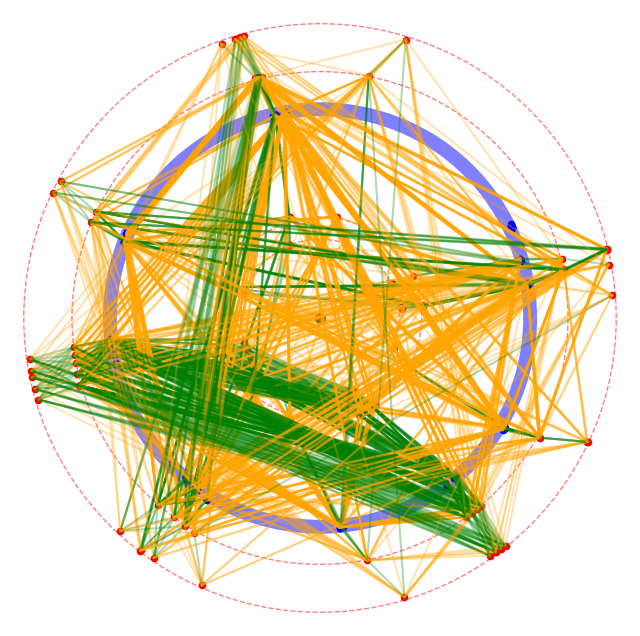

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
plot_detector(ax)
#plot_graph_to_axis(ax, layer_separated_hetero_graph_dataset[0], no_edges=False)
plot_layer_hetero_graph_to_axis(ax, layer_separated_hetero_graph_dataset[3], no_edges=False)

In [ ]:
layer_separated_hetero_graph_dataset[0]["mppc"].x

In [ ]:
layer_separated_hetero_graph_dataset[1]["mppc"].x

In [ ]:
layer_separated_hetero_graph_dataset[1]["mppc"].track_truth